# **ARIMA Model**

Notebook analyzes prediction power of the **ARIMA** model, applied on the univariate time-series of previous closing prices. For the purposes of tuning the model, we used library <code>pmdarima</code>, which uses concept of grid search to find optimal combinations of <code>(p, d, q)</code> (in terms of Bayesian Information Criterion). This is the reason, why no further optimization of single parameters is displayed.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
import pmdarima

import warnings

warnings.filterwarnings("ignore")


In [2]:
# Pre-processed data preparation
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

# **ARIMA Univariate**

In [3]:
# To track how well predictions work, all metrics -> dominance, MAPE/APE and benchmark performance
performance_tracker = {}
performance_simple = {}
model_dominance = {}

for ticker in tickers["Ticker"]:
    # Bounded training-validation set
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    # Training length chosen ad hoc
    training_length = 20 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_simple[ticker] = []
    model_dominance[ticker] = []

    MAPEs = []
    AccuracyToSimple = []
    dominance_dates = []
    # Rolling windows for single stock
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = pmdarima.auto_arima(y=Training_Target)
 
        prediction = MODEL.predict(n_periods=prediction_length)
        
        AccuracyToSimple.append(mean_absolute_percentage_error(Test_Target, prediction) <= (mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]])))
        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        
        if mean_absolute_percentage_error(Test_Target, prediction) <= mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]):
            dominance_dates.append(str(Stock_Data["Date"].iloc[window_start+training_length+prediction_length].date()))                                                        

        print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))    
        
    performance_simple[ticker] = AccuracyToSimple.copy()
    performance_tracker[ticker] = MAPEs.copy()
    model_dominance[ticker] = dominance_dates.copy()

ACN 0.6600623841758388
ACN 0.32542991165928775
ACN 0.01841515323100088
ACN 0.2635102549259541
ACN 1.06770246633684
ACN 0.8305269112553613
ACN 0.1148780756828569
ACN 0.30236863880588305
ACN 1.5939689312449719
ACN 0.3426039538257704
ACN 1.61084553065292
ACN 0.23718274887210372
ACN 1.035123822796044
ACN 0.10690103139506318
ACN 0.03240458204125198
ACN 0.11338948525434303
ACN 0.3822642993402214
ACN 0.5831318216215097
ACN 0.6722246933238964
ACN 0.9940328989568034
ACN 0.1764891602979046
ACN 0.20344979906374286
ACN 0.47779322696144466
ACN 0.7603673550917639
ACN 1.68875423100885
ACN 1.3663444252566623
ACN 0.18634292054187676
ACN 0.9980656563161345
ACN 0.4514647282446601
ACN 0.19005893252532602
ACN 0.1702985632687678
ACN 0.044797716532624425
ACN 0.8814424413927627
ACN 0.0030722100434029836
ACN 0.76133245687243
ACN 0.2128247653677826
ACN 0.5914812654110874
ACN 0.42228280655084915
ACN 0.2582159590792689
ACN 1.145470656518153
ACN 0.5495793728041252
ACN 0.6294941769837179
ACN 0.5531196258119955
ACN 

In [4]:
# Mean dominance from all stocks
means_prevalences = [np.mean(i) for i in performance_simple.values()]
print(100*np.mean(means_prevalences))

58.24695121951219


In [5]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [6]:
# MAPE from all stocks
print(np.mean(list(mean_performances.values())))

1.897112816084953


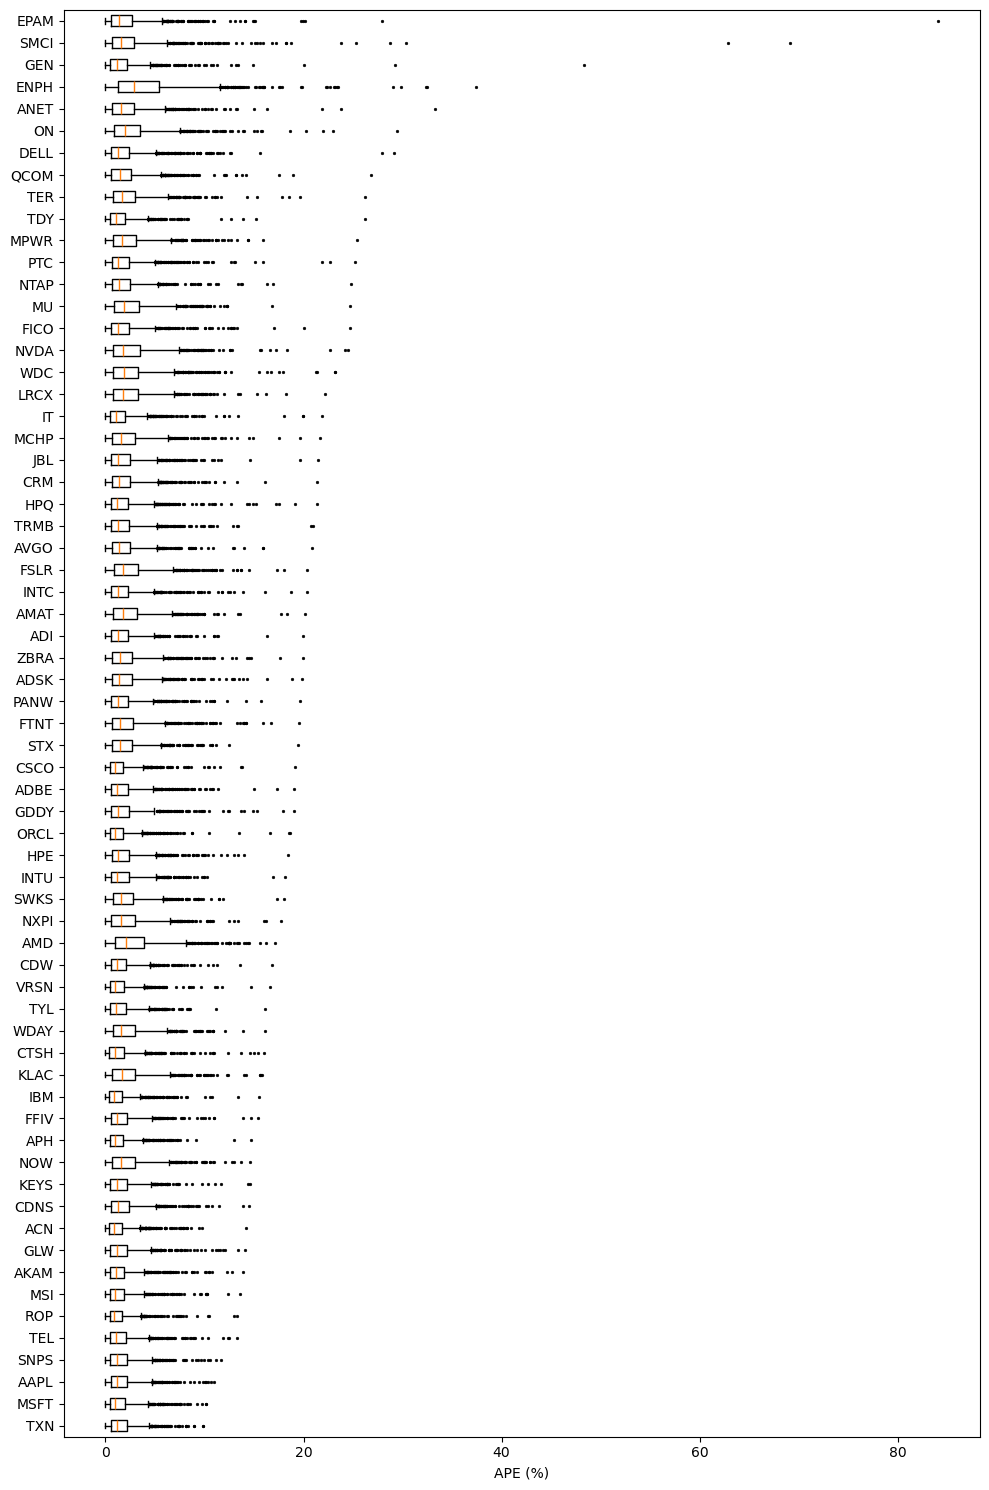

In [7]:
plt.figure(figsize=(10, 15))

plt.boxplot(
    performance_tracker[list(range_performances.keys())],
    vert=False,
    showmeans=False,
    flierprops=dict(
        marker='o',
        markersize=2,      # 👈 smaller dots (default is ~6)
        markerfacecolor='black',
        markeredgewidth=0.3
    )
)

plt.xlabel("APE (%)")
plt.yticks(range(1, len(range_performances.keys()) + 1),
           list(range_performances.keys()))

plt.tight_layout()
plt.show()

In [8]:
print(mean_performances)

{'ROP': np.float64(1.256167532921982), 'IBM': np.float64(1.2895414215766534), 'ACN': np.float64(1.307295741160988), 'ORCL': np.float64(1.3491198643292177), 'MSI': np.float64(1.3750706047938415), 'APH': np.float64(1.3766324426930485), 'VRSN': np.float64(1.3809413165762712), 'CSCO': np.float64(1.3884301372915606), 'AKAM': np.float64(1.4517547380944444), 'MSFT': np.float64(1.4609929140746574), 'CTSH': np.float64(1.4636875964525875), 'TDY': np.float64(1.4986177430547887), 'TYL': np.float64(1.5229854558451952), 'TEL': np.float64(1.5370286676166138), 'TXN': np.float64(1.5771557633537465), 'CDW': np.float64(1.5776432980599193), 'FFIV': np.float64(1.5942269915417546), 'AAPL': np.float64(1.598365448475383), 'KEYS': np.float64(1.6016526007653704), 'IT': np.float64(1.603948516471633), 'GLW': np.float64(1.6080810079734797), 'SNPS': np.float64(1.6533953612273917), 'GEN': np.float64(1.691536218746048), 'ADI': np.float64(1.692957956325842), 'ADBE': np.float64(1.7443228298901874), 'INTU': np.float64(1

Dominance of model in single rolling windows was analyzed. Particularly, we analyzed how well model performed in time for chosen stocks. Even though this analysis was not included in the final thesis text, we decided to leave it in the source codes.

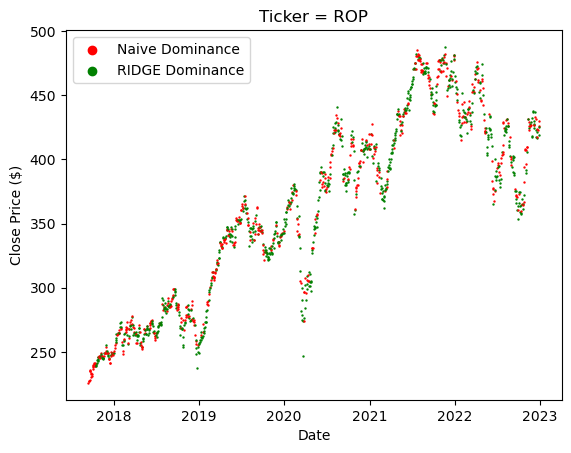

In [9]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ROP"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

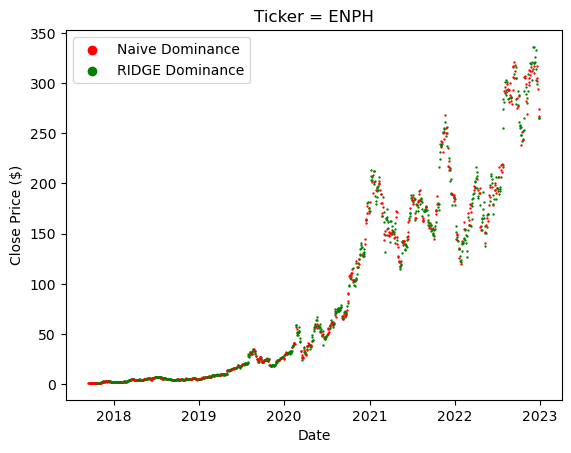

In [10]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "ENPH"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

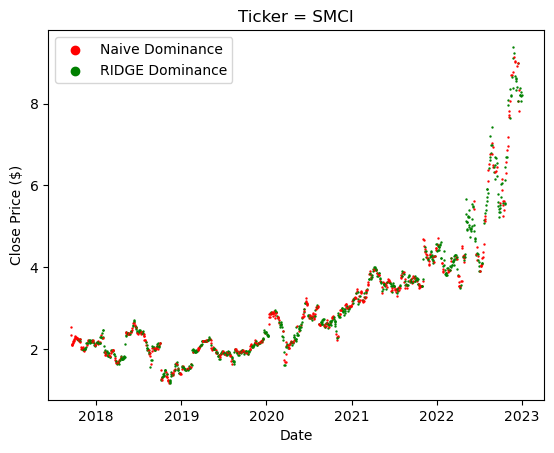

In [11]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "SMCI"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

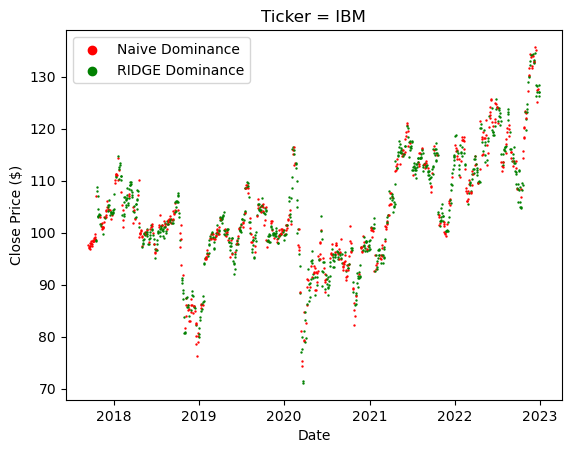

In [12]:
colors = {'A':'red', 'B':'green'}
for label, color in colors.items():
    plt.scatter([], [], c=color, label=label)  # invisible points for legend

ticker = "IBM"
Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14' AND Date<='2022-12-31'", con=StockDataDatabase, parse_dates=["Date"])
    
for i in range(len(Stock_Data)):
    date = Stock_Data.iloc[i]["Date"]
    close_price = Stock_Data.iloc[i]["Close"]

    if str(Stock_Data.iloc[i]["Date"].date()) in model_dominance[f"{ticker}"]:
        plt.scatter(date, close_price, c="green", s=0.5)
    else:
        plt.scatter(date, close_price, c="red", s=0.5)

plt.legend(title="Category")
plt.legend(["Naive Dominance", "RIDGE Dominance"])
plt.title(f"Ticker = {ticker}")

plt.xlabel("Date")
plt.ylabel("Close Price ($)")

plt.show()

# **Analysis of dominance in detail**

Apart from the analysis of performance in the whole time interval, we analyzed performance of models in major event on the market during the analyzed period. 

We analyzed COVID-19 period and Trump tarrifs, but nothing in particular was found.

In [13]:
# COVID-19
# We perform analysis of precision between February and March 2020 -> Covid recession

# Number of trading days -> 41 days
trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= "2020-02-01") & (TrainingDataFrame["Date"] <= "2020-03-31")]["Date"].values
trading_days = [str(i).split("T")[0] for i in trading_days]

covid_dominances = {}

for ticker in tickers["Ticker"]:
    counter = 0
    for day in model_dominance[ticker]:
        if day in trading_days:
            counter += 1
    covid_dominances[ticker] = counter*100 / len(trading_days)

print(np.mean(list(covid_dominances.values())))

58.98686679174485


In [14]:
sorted(covid_dominances.items(), key=lambda x: x[1], reverse=True)

[('NOW', 78.04878048780488),
 ('CTSH', 73.17073170731707),
 ('FICO', 73.17073170731707),
 ('FSLR', 73.17073170731707),
 ('INTC', 73.17073170731707),
 ('INTU', 70.73170731707317),
 ('TEL', 70.73170731707317),
 ('TYL', 70.73170731707317),
 ('AAPL', 68.29268292682927),
 ('ENPH', 68.29268292682927),
 ('MU', 68.29268292682927),
 ('MSI', 68.29268292682927),
 ('PTC', 68.29268292682927),
 ('QCOM', 68.29268292682927),
 ('CDW', 65.85365853658537),
 ('GEN', 65.85365853658537),
 ('KEYS', 65.85365853658537),
 ('LRCX', 65.85365853658537),
 ('ADBE', 63.41463414634146),
 ('ADI', 63.41463414634146),
 ('MSFT', 63.41463414634146),
 ('NXPI', 63.41463414634146),
 ('ON', 63.41463414634146),
 ('WDC', 63.41463414634146),
 ('FFIV', 60.97560975609756),
 ('IT', 60.97560975609756),
 ('IBM', 60.97560975609756),
 ('KLAC', 60.97560975609756),
 ('ROP', 60.97560975609756),
 ('STX', 60.97560975609756),
 ('AMAT', 58.53658536585366),
 ('GLW', 58.53658536585366),
 ('EPAM', 58.53658536585366),
 ('SWKS', 58.53658536585366),

In [15]:
# Trumpove mecheche
# We perform analysis of precision between of April 2025 -> Trump's tarrifs

# Number of trading days -> 41 days
trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= "2025-04-01") & (TrainingDataFrame["Date"] <= "2025-04-30")]["Date"].values
trading_days = [str(i).split("T")[0] for i in trading_days]

trump_dominances = {}

for ticker in tickers["Ticker"]:
    counter = 0
    for day in model_dominance[ticker]:
        if day in trading_days:
            counter += 1
    trump_dominances[ticker] = counter*100 / len(trading_days)

print(np.mean(list(trump_dominances.values())))

0.0


In [16]:
sorted(trump_dominances.items(), key=lambda x: x[1], reverse=True)

[('ACN', 0.0),
 ('ADBE', 0.0),
 ('AMD', 0.0),
 ('AKAM', 0.0),
 ('APH', 0.0),
 ('ADI', 0.0),
 ('AAPL', 0.0),
 ('AMAT', 0.0),
 ('ANET', 0.0),
 ('ADSK', 0.0),
 ('AVGO', 0.0),
 ('CDNS', 0.0),
 ('CDW', 0.0),
 ('CSCO', 0.0),
 ('CTSH', 0.0),
 ('GLW', 0.0),
 ('DELL', 0.0),
 ('ENPH', 0.0),
 ('EPAM', 0.0),
 ('FFIV', 0.0),
 ('FICO', 0.0),
 ('FSLR', 0.0),
 ('FTNT', 0.0),
 ('IT', 0.0),
 ('GEN', 0.0),
 ('GDDY', 0.0),
 ('HPE', 0.0),
 ('HPQ', 0.0),
 ('IBM', 0.0),
 ('INTC', 0.0),
 ('INTU', 0.0),
 ('JBL', 0.0),
 ('KEYS', 0.0),
 ('KLAC', 0.0),
 ('LRCX', 0.0),
 ('MCHP', 0.0),
 ('MU', 0.0),
 ('MSFT', 0.0),
 ('MPWR', 0.0),
 ('MSI', 0.0),
 ('NTAP', 0.0),
 ('NVDA', 0.0),
 ('NXPI', 0.0),
 ('ON', 0.0),
 ('ORCL', 0.0),
 ('PANW', 0.0),
 ('PTC', 0.0),
 ('QCOM', 0.0),
 ('ROP', 0.0),
 ('CRM', 0.0),
 ('STX', 0.0),
 ('NOW', 0.0),
 ('SWKS', 0.0),
 ('SMCI', 0.0),
 ('SNPS', 0.0),
 ('TEL', 0.0),
 ('TDY', 0.0),
 ('TER', 0.0),
 ('TXN', 0.0),
 ('TRMB', 0.0),
 ('TYL', 0.0),
 ('VRSN', 0.0),
 ('WDC', 0.0),
 ('WDAY', 0.0),
 ('ZB

Lastly, dominance per single year is depicted. This shows rather stability of the model during the periods.

In [17]:
years = [str(i) for i in range(2017, 2023)]
dominances = []

for year in years:
    trading_days = TrainingDataFrame[(TrainingDataFrame["Date"] >= f"{year}-01-01") & (TrainingDataFrame["Date"] <= f"{year}-12-31")]["Date"].values
    trading_days = [str(i).split("T")[0] for i in trading_days]

    year_dominances = {}

    for ticker in tickers["Ticker"]:
        counter = 0
        for day in model_dominance[ticker]:
            if day in trading_days:
                counter += 1
        year_dominances[ticker] = counter*100 / len(trading_days)

    dominances.append(np.mean(list(year_dominances.values())))
    print(year, np.mean(list(year_dominances.values())))

2017 41.78794178794179
2018 57.50536316273368
2019 58.907203907203915
2020 58.218303435694736
2021 57.246642246642246
2022 59.33803248544284
